Ta koda je namenjena racunanju in predstavitvi korelacije med izbranimi tickerji. Ugotovitve nam lahko pomagajo pri izbiranju pravih investicij za diverzificeran portfolij.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Importa vse potrebne knjiznice

In [5]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "CLFD", "NVDA"]

Izbrani tickerji

In [6]:
start_date = "2024-01-01"
end_date = "2026-06-15"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

[*********************100%***********************]  6 of 6 completed


Povlece potrebne podatke o izbranih tickerjih

In [7]:
log_returns = np.log(data / data.shift(1)).dropna()

corr_matrix = log_returns.corr()

Izracuna, glede na podatke, ter ustvari matriko. Uporabljamo logaritme, saj so bolj optimalni za dolgo rocno racunanje. Vresnici isemo log od (danasnji dan)/(vceraj). Dropna() samo odstrani prvo vrstico, saj ne obstaja -1 dan.

Corr_matrix pa je samo matrika, s kateri izracunamo korelacijo med tickerji.

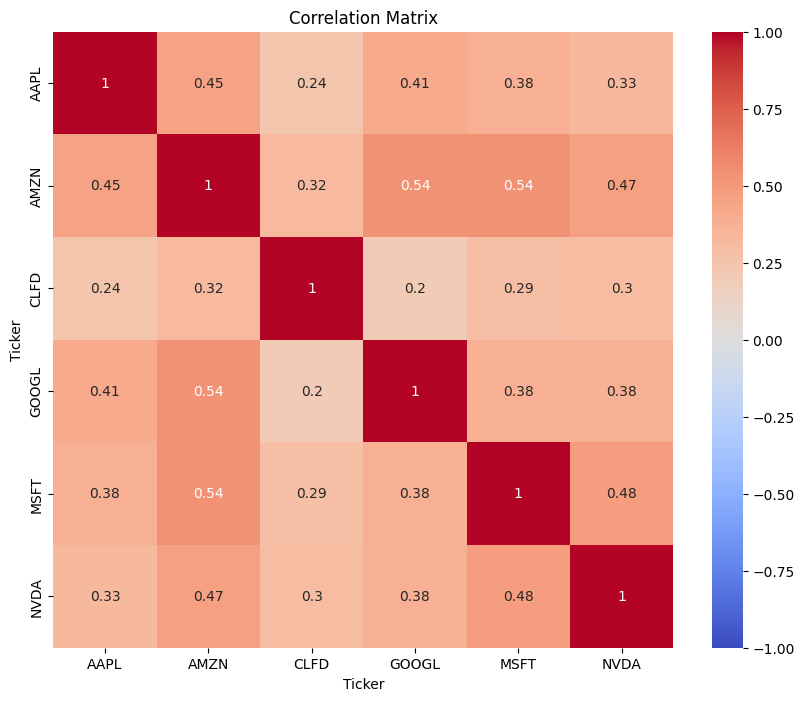

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

Vizualizacija korelacij v izbranem casovnem obdobju

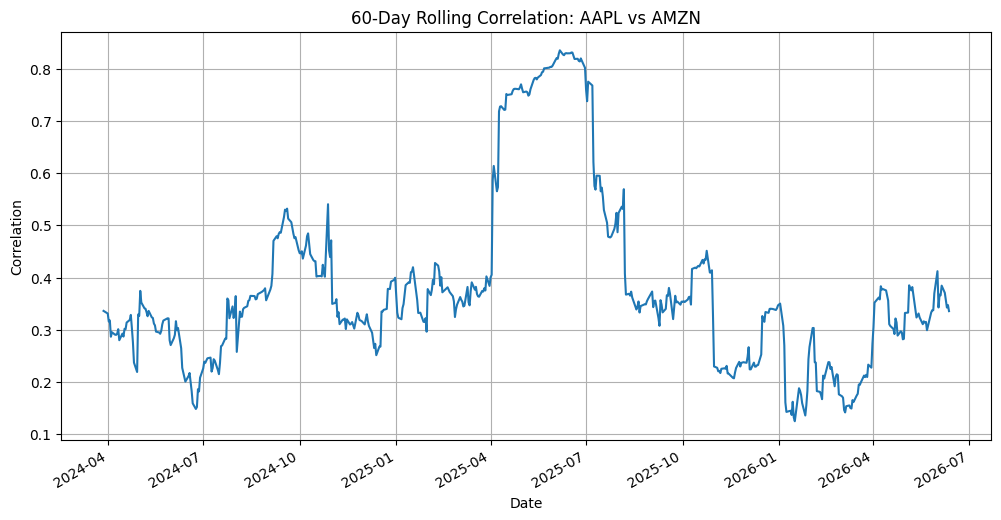

In [9]:
asset1 = "AAPL"
asset2 = "AMZN"

rolling_corr = (
    log_returns[asset1]
    .rolling(60)
    .corr(log_returns[asset2])
)

plt.figure(figsize=(12,6))
rolling_corr.plot()

plt.title(f"60-Day Rolling Correlation: {asset1} vs {asset2}")
plt.ylabel("Correlation")
plt.grid(True)

plt.show()

Tukaj imamo rolling correlation graf. Heatmap nam poda le povprecno korelacijo v izbranem casovnem obdobju, medtem ko nam graf pove kako se korelacija spreminja skozi cas. Visje kot je krivulja, vecja je korelacija dveh izbranih tickerjev, kar pomeni, da se bolj povezano gibljeta.

In [10]:
avg_corr = corr_matrix.mean().sort_values()

print(avg_corr)

Ticker
CLFD     0.392450
AAPL     0.467689
GOOGL    0.482987
NVDA     0.492963
MSFT     0.511844
AMZN     0.551953
dtype: float64


avg_corr nam vrne seznam, po vrstnem redu, vse tickerje in njihovo "oddaljenost" od ostalih tickerjev. Torej tisti ticker, ki ima najmanjso vrednost, je najbolj unikaten v nasem naboru.

In [11]:
summary = pd.DataFrame()

summary["Avg Corr"] = avg_corr
summary["Annual Return"] = log_returns.mean() * 252
summary["Annual Volatility"] = log_returns.std() * np.sqrt(252)

summary.sort_values("Avg Corr")

,Avg Corr,Annual Return,Annual Volatility
Ticker,,,
CLFD,0.392450,0.115252,0.515691
AAPL,0.467689,0.189603,0.271172
GOOGL,0.482987,0.396934,0.301445
NVDA,0.492963,0.596503,0.488659
MSFT,0.511844,0.029366,0.245309
AMZN,0.551953,0.190916,0.311533


Summary samo ustvari prazno tabelo, v katero bo program vstavljal podatke. Annual return je izracun letnega donosa (252 namesto 356, saj je toliko "trading" dni v letu). Volatillity pa izracuna letni volatilitj izbranega tickerja. 

In [12]:
summary["Return / Risk"] = summary["Annual Return"] / summary["Annual Volatility"]

summary.sort_values("Return / Risk", ascending=False)

,Avg Corr,Annual Return,Annual Volatility,Return / Risk
Ticker,,,,
GOOGL,0.482987,0.396934,0.301445,1.316771
NVDA,0.492963,0.596503,0.488659,1.220693
AAPL,0.467689,0.189603,0.271172,0.699199
AMZN,0.551953,0.190916,0.311533,0.612827
CLFD,0.392450,0.115252,0.515691,0.223490
MSFT,0.511844,0.029366,0.245309,0.119710


To izracuna razmerje in ga prikaze. Gre za donos : volatilitij.

In [13]:
def allocation_from_summary(summary, min_weight=0.03):
    scores = (
        summary["Annual Return"] / summary["Annual Volatility"]
    ) * (1 - summary["Avg Corr"])

    scores = scores.clip(lower=0)

    weights = scores / scores.sum()

    weights = weights[weights >= min_weight]

    weights = weights / weights.sum()

    allocation = pd.DataFrame()
    allocation["Weight"] = weights
    allocation["Weight %"] = allocation["Weight"] * 100

    return allocation.sort_values("Weight", ascending=False)

In [14]:
allocation = allocation_from_summary(summary)

allocation

,Weight,Weight %
Ticker,,
GOOGL,0.326945,32.694456
NVDA,0.297241,29.724098
AAPL,0.178743,17.874290
AMZN,0.131863,13.186339
CLFD,0.065208,6.520817


Kodi v prejsnih dveh celicah nam izracunata in predstavita izbiro najboljsih tickerjev v nasem prvotnem naboru. Minimalna utez je podana, saj tako omeji in odstrani tickerje, ki niso primerni za nas portfolij. Izracuna nam score (score = (Annual Return / Annual Volatility) × (1 - Avg Corr)). Prvi del je samo preprosta oblika Sharpe razmerja. Drugi del pa uporabimo, saj zelimo poleg Sharpe razmerja pogledati se korelacijo med tickerji. Torej dober donos + nizko tveganje + dobro diverzifikacijo.

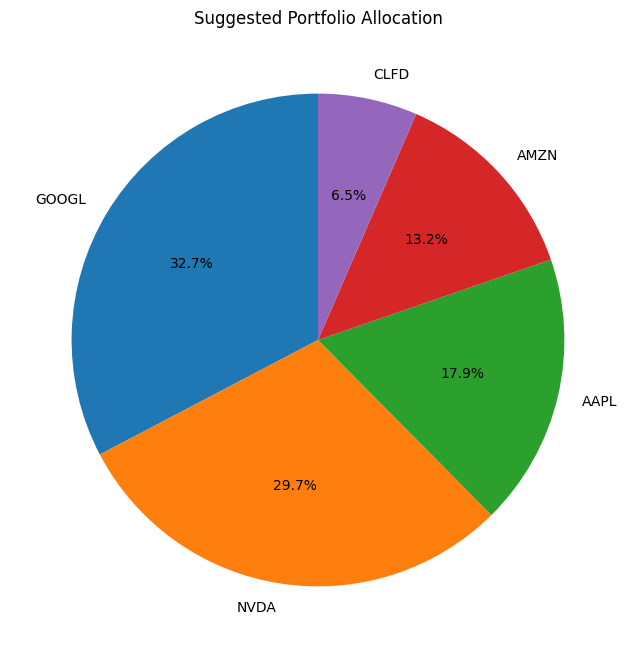

In [15]:
plt.figure(figsize=(8, 8))

plt.pie(
    allocation["Weight"],
    labels=allocation.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Suggested Portfolio Allocation")
plt.show()